In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# TASK 1

C:\Users\Vito\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Vito\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Vito\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Vito\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows wi

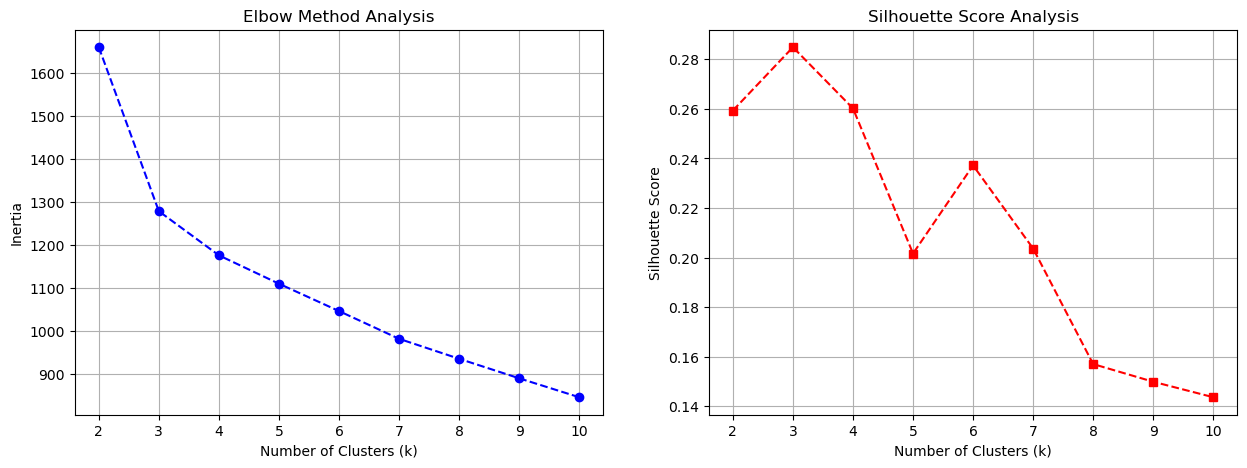

C:\Users\Vito\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


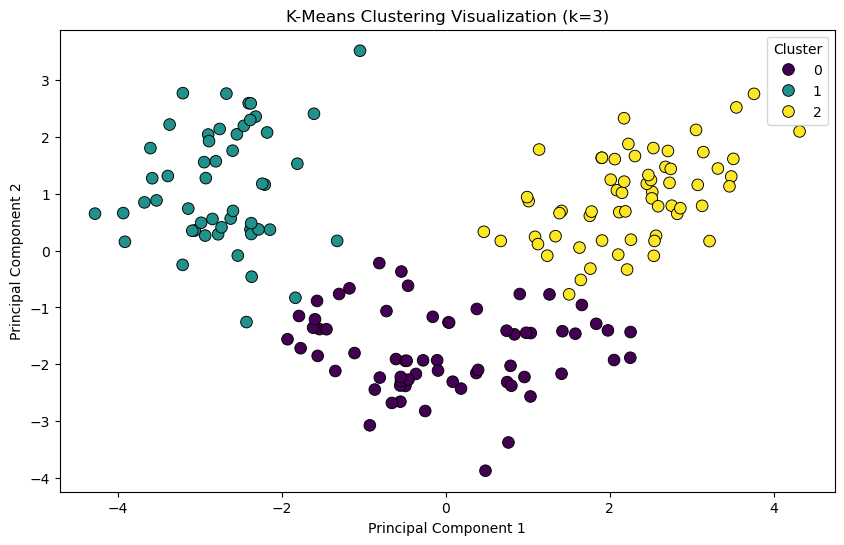

In [2]:
wine_data = load_wine()
X = wine_data.data
y = wine_data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia_values = []
silhouette_values = []
k_range = range(2, 11)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    inertia_values.append(model.inertia_)
    silhouette_values.append(silhouette_score(X_scaled, labels))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(k_range, inertia_values, marker='o', linestyle='--', color='b')
ax[0].set_title('Elbow Method Analysis')
ax[0].set_xlabel('Number of Clusters (k)')
ax[0].set_ylabel('Inertia')
ax[0].grid(True)

ax[1].plot(k_range, silhouette_values, marker='s', linestyle='--', color='r')
ax[1].set_title('Silhouette Score Analysis')
ax[1].set_xlabel('Number of Clusters (k)')
ax[1].set_ylabel('Silhouette Score')
ax[1].grid(True)

plt.show()

optimal_k = 3
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
final_labels = final_kmeans.fit_predict(X_scaled)

pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=final_labels, palette='viridis', s=70, edgecolor='black')
plt.title(f'K-Means Clustering Visualization (k={optimal_k})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

## Optimal k Selection and Justification

**Why k=3?**

The elbow curve shows a sharp drop in inertia from k=2 to k=3 (~390 units),
after which the decrease flattens significantly. Adding more clusters beyond
k=3 yields diminishing returns — the extra complexity is not justified.

The silhouette score peaks at k=3 (≈0.285) and declines consistently after.
A higher silhouette score means points are well-matched to their own cluster
and clearly separated from neighboring clusters. Both metrics independently|
agree on k=3, which is strong evidence — they measure different things
(compactness vs. separation), so agreement is not a coincidence.

The PCA scatter plot confirms this: three spatially distinct groups with
minimal overlap emerge after reducing 13 dimensions to 2, meaning the
separation is genuine and not an artifact of the method.

**Note:** The Wine dataset contains exactly 3 cultivars, so k=3 also aligns
with the known ground truth — unsupervised clustering recovered the real
structure without ever seeing the labels.

# TASK 2

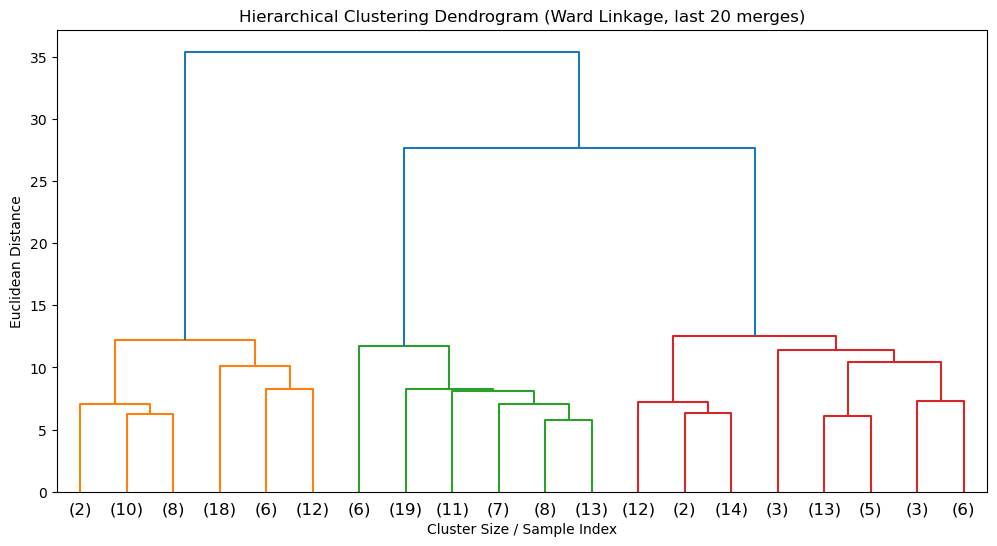

Systematic DBSCAN Comparison:
 Eps  MinSamples  Clusters  Noise
 1.5           5         0    178
 2.0           5         5     85
 2.5           4         1     23

Best DBSCAN config: eps=2.0, min_samples=5
Clusters found: 5, Noise points: 85


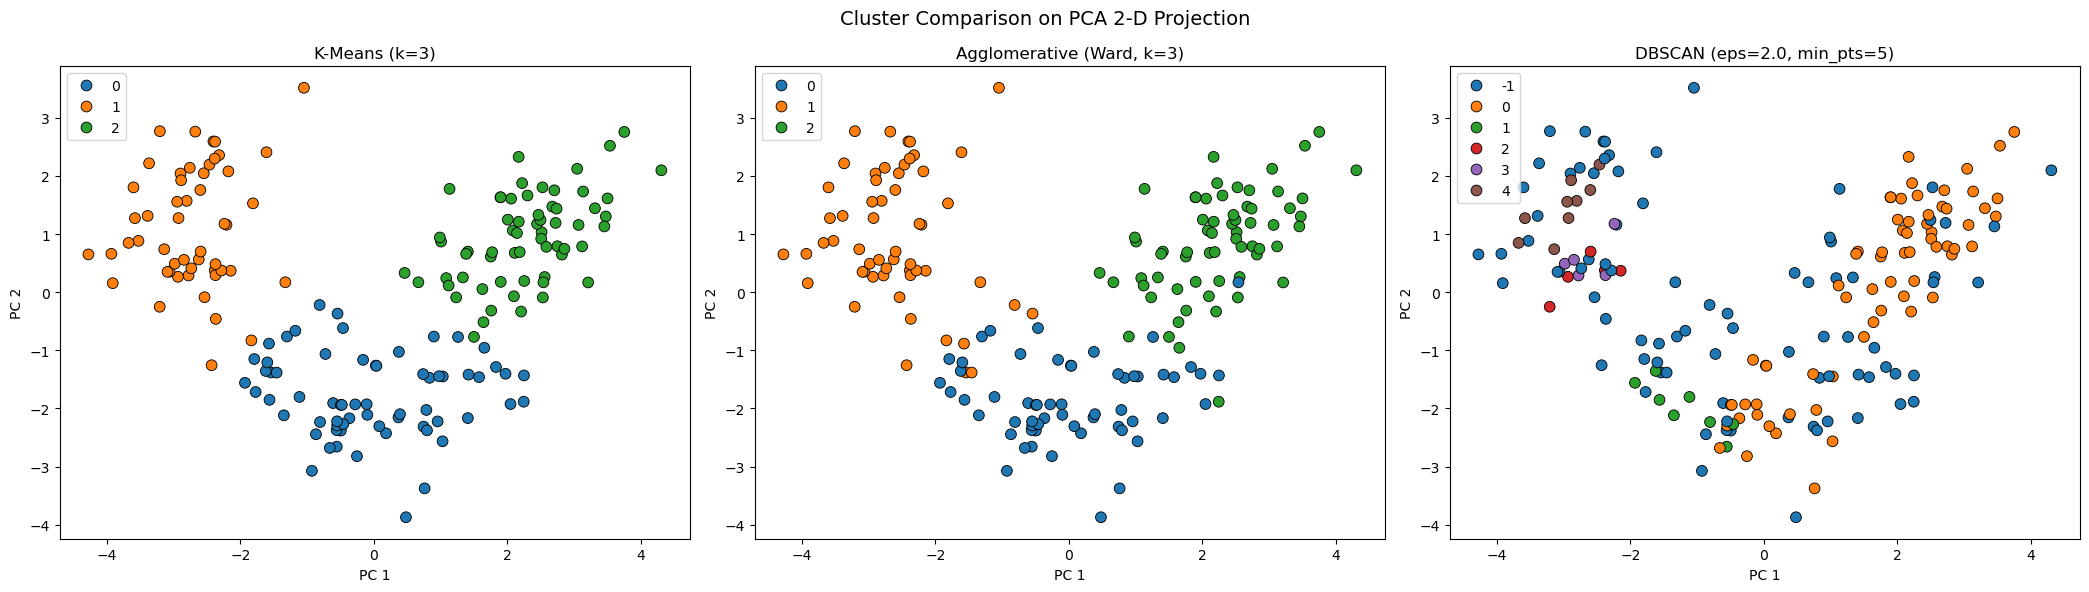

In [3]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, DBSCAN

# --- 2.1 Agglomerative Clustering (same k=3 as Task 1) ---
agg_model = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
agg_labels = agg_model.fit_predict(X_scaled)

# --- 2.2 Dendrogram (truncated to last 20 merges) ---
hierarchical_linkage = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(hierarchical_linkage, truncate_mode='lastp', p=20)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage, last 20 merges)')
plt.xlabel('Cluster Size / Sample Index')
plt.ylabel('Euclidean Distance')
plt.show()

# --- 2.3 DBSCAN: at least 3 (eps, min_samples) combinations ---
eps_values       = [1.5, 2.0, 2.5]
min_samples_values = [5,   5,   4]
dbscan_results = []
dbscan_all_labels = []

for eps, min_pts in zip(eps_values, min_samples_values):
    dbscan_model = DBSCAN(eps=eps, min_samples=min_pts)
    db_labels = dbscan_model.fit_predict(X_scaled)
    unique_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    noise_count = list(db_labels).count(-1)
    dbscan_results.append({'Eps': eps, 'MinSamples': min_pts,
                           'Clusters': unique_clusters, 'Noise': noise_count})
    dbscan_all_labels.append(db_labels)

dbscan_summary_df = pd.DataFrame(dbscan_results)
print("Systematic DBSCAN Comparison:")
print(dbscan_summary_df.to_string(index=False))

# --- 2.4 Select best DBSCAN config (cluster count closest to optimal_k=3) ---
best_idx = (dbscan_summary_df['Clusters'] - optimal_k).abs().idxmin()
best_dbscan_labels = dbscan_all_labels[best_idx]
best_eps     = dbscan_summary_df.loc[best_idx, 'Eps']
best_min_pts = dbscan_summary_df.loc[best_idx, 'MinSamples']
print(f"\nBest DBSCAN config: eps={best_eps}, min_samples={best_min_pts}")
print(f"Clusters found: {dbscan_summary_df.loc[best_idx, 'Clusters']}, "
      f"Noise points: {dbscan_summary_df.loc[best_idx, 'Noise']}")

# --- 2.5 Side-by-side PCA comparison: KMeans | Agglomerative | DBSCAN ---
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('Cluster Comparison on PCA 2-D Projection', fontsize=14)

for ax, labels, title in zip(axes,
                              [final_labels, agg_labels, best_dbscan_labels],
                              ['K-Means (k=3)', 'Agglomerative (Ward, k=3)',
                               f'DBSCAN (eps={best_eps}, min_pts={best_min_pts})']):
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels,
                    palette='tab10', ax=ax, s=60, edgecolor='black')
    ax.set_title(title)
    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')

plt.tight_layout()
plt.show()

## Clustering Approach Comparison

**K-Means and Agglomerative (Ward) produced the most coherent clusters.**
Their PCA projections are nearly identical — only a few boundary points differ.
This is expected: Ward linkage minimizes within-cluster variance at each merge,
which is mathematically similar to K-Means' objective.

The dendrogram reinforces k=3: three large branches merge only at a Euclidean
distance of ~35, while within-group merges happen below ~12. The large gap
signals that splitting into fewer than 3 groups would lose significant structure.

**DBSCAN struggled on this dataset.**
At eps=1.5 all 178 points were classified as noise — the threshold was too tight.
At eps=2.0 it found 5 clusters but left 85 points (nearly half the data) as noise.
At eps=2.5 almost everything collapsed into 1 cluster.

The root cause: the scaled Wine data has roughly uniform density in 13-dimensional
space, with no clear low-density gaps between groups. DBSCAN needs those gaps to
define cluster boundaries. K-Means and Agglomerative make no such assumption,
which is why they work better here.

# TASK 3

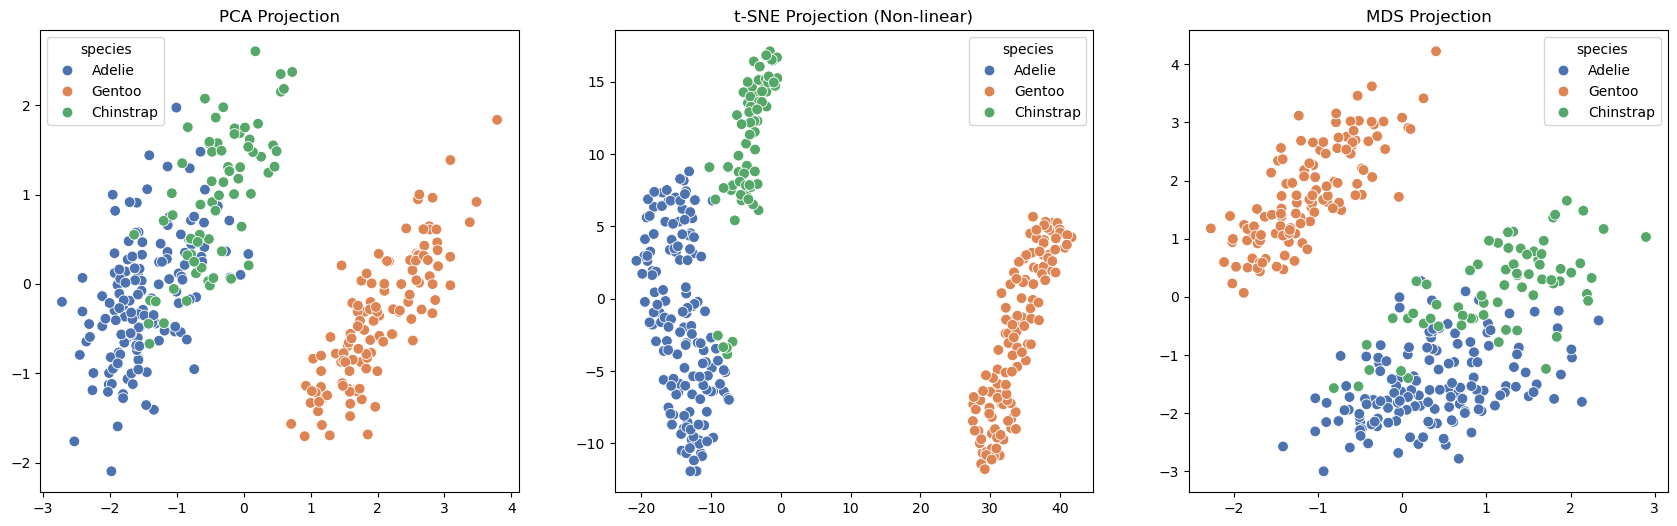

In [4]:
from palmerpenguins import load_penguins
from sklearn.manifold import TSNE, MDS

penguin_df = load_penguins().dropna()
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X_penguins = penguin_df[features]
y_penguins = penguin_df['species']

X_penguins_scaled = StandardScaler().fit_transform(X_penguins)

pca_model = PCA(n_components=2)
tsne_model = TSNE(n_components=2, random_state=42, perplexity=30)
mds_model = MDS(n_components=2, random_state=42, normalized_stress='auto')

res_pca = pca_model.fit_transform(X_penguins_scaled)
res_tsne = tsne_model.fit_transform(X_penguins_scaled)
res_mds = mds_model.fit_transform(X_penguins_scaled)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

sns.scatterplot(x=res_pca[:, 0], y=res_pca[:, 1], hue=y_penguins, ax=axes[0], palette='deep', s=60)
axes[0].set_title('PCA Projection')

sns.scatterplot(x=res_tsne[:, 0], y=res_tsne[:, 1], hue=y_penguins, ax=axes[1], palette='deep', s=60)
axes[1].set_title('t-SNE Projection (Non-linear)')

sns.scatterplot(x=res_mds[:, 0], y=res_mds[:, 1], hue=y_penguins, ax=axes[2], palette='deep', s=60)
axes[2].set_title('MDS Projection')

plt.show()

## Dimensionality Reduction Discussion

**Best visual separation: t-SNE.**
It produces the tightest, most distinct clusters of the three methods.
Adelie and Chinstrap, which overlap in PCA and MDS, appear more separated.

**Most distance distortion: t-SNE.**
t-SNE optimizes local neighborhood structure — points that are close stay close,
but the distances *between* clusters carry no reliable meaning. PCA and MDS
are global methods that preserve overall geometry, so inter-cluster distances
in those plots are more interpretable.

**Why t-SNE gives different results on repeated runs:**
t-SNE uses random initialization followed by gradient descent. Different random
seeds lead to different local minima, producing different-looking layouts even
on the same data. Setting random_state=42 makes results reproducible, but the
layout is seed-dependent — not a unique "correct" answer.

**Practical takeaway:** Use t-SNE to answer "do clusters exist?" Use PCA or MDS
when the actual distances between groups matter.

# TASK 4

C:\Users\Vito\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Performance Metrics on Penguins Dataset:
                             Metric    Value
          Adjusted Rand Index (ARI) 0.799421
Normalized Mutual Information (NMI) 0.789932


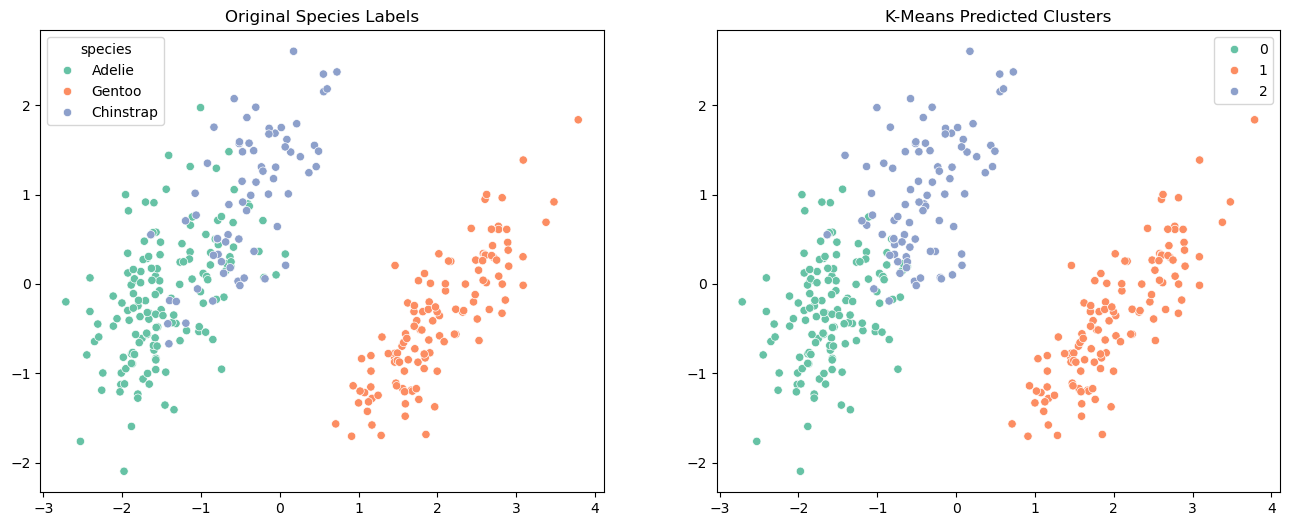

In [5]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

penguin_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
penguin_clusters = penguin_kmeans.fit_predict(X_penguins_scaled)

ari_val = adjusted_rand_score(y_penguins, penguin_clusters)
nmi_val = normalized_mutual_info_score(y_penguins, penguin_clusters)

evaluation_metrics = pd.DataFrame({
    'Metric': ['Adjusted Rand Index (ARI)', 'Normalized Mutual Information (NMI)'],
    'Value': [ari_val, nmi_val]
})

print("Performance Metrics on Penguins Dataset:")
print(evaluation_metrics.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(x=res_pca[:, 0], y=res_pca[:, 1], hue=y_penguins, ax=axes[0], palette='Set2')
axes[0].set_title('Original Species Labels')

sns.scatterplot(x=res_pca[:, 0], y=res_pca[:, 1], hue=penguin_clusters, ax=axes[1], palette='Set2')
axes[1].set_title('K-Means Predicted Clusters')

plt.show()

## Unsupervised Learning Performance Analysis

**Metrics:**
- Adjusted Rand Index (ARI): 0.799
- Normalized Mutual Information (NMI): 0.789

ARI measures how often pairs of points are grouped the same way by K-Means
and by the true labels. A score of 0.799 means roughly 80% agreement —
strong alignment for a fully unsupervised method.
NMI measures how much information the cluster assignments share with the true
species labels. At 0.789, knowing the cluster predicts the species with ~79%
reliability.

**Where it succeeded:** Gentoo penguins were isolated almost perfectly.
Their body mass (~5000g) and flipper length are distinctly larger than the
other two species, creating a well-separated region in feature space that
K-Means easily finds.

**Where it struggled:** Adelie and Chinstrap share similar measurements across
all four features. K-Means draws a linear boundary between them, but the real
biological boundary does not follow that shape — some points are inevitably
misassigned.

**Conclusion:** Unsupervised methods can substitute for labeled data when
classes are naturally separated in the measured feature space. When class
differences come from features that were not measured, or when boundaries are
non-linear, supervised learning with explicit labels becomes necessary.